# Capítulo 1: Descarga y Exploración de Datos

## 1.1 Fuente de datos

Se utiliza la API pública de **Yahoo Finance** a través de la librería `yfinance` para obtener la serie histórica completa del precio de cierre diario de Bitcoin (`BTC-USD`).

:::{admonition} Justificación del ticker
:class: note
El ticker `BTC-USD` en Yahoo Finance corresponde al precio spot de Bitcoin cotizado en dólares americanos. Aunque el enunciado refiere a *futuros*, Yahoo Finance no provee datos continuos de futuros de BTC con suficiente historia; el precio spot es el proxy estándar usado en la literatura académica de series de tiempo financieras.
:::


In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

TICKER = 'BTC-USD'
START  = '2014-09-17'
END    = datetime.today().strftime('%Y-%m-%d')

raw = yf.download(TICKER, start=START, end=END, progress=False)
btc = raw[['Close']].copy()
btc.columns = ['Price']
btc.index   = pd.DatetimeIndex(btc.index).normalize()
btc.dropna(inplace=True)

print(f'Ticker        : {TICKER}')
print(f'Rango         : {btc.index[0].date()} -> {btc.index[-1].date()}')
print(f'Observaciones : {len(btc):,}')
print(f'Precio min    : ${btc.Price.min():,.2f}')
print(f'Precio max    : ${btc.Price.max():,.2f}')
print(f'Precio actual : ${btc.Price.iloc[-1]:,.2f}')

Ticker        : BTC-USD
Rango         : 2014-09-17 -> 2026-04-03
Observaciones : 4,217
Precio min    : $178.10
Precio max    : $124,752.53
Precio actual : $66,931.10


## 1.2 Estadísticas descriptivas

In [2]:
btc['LogReturn'] = np.log(btc.Price / btc.Price.shift(1))

desc = btc.describe()
print('=== Estadisticas Descriptivas ===')
print(desc.round(4))
print()
print(f'Curtosis  (Price)     : {btc.Price.kurtosis():.4f}')
print(f'Asimetria (Price)     : {btc.Price.skew():.4f}')
print(f'Curtosis  (LogReturn) : {btc.LogReturn.kurtosis():.4f}')
print(f'Asimetria (LogReturn) : {btc.LogReturn.skew():.4f}')

=== Estadisticas Descriptivas ===
             Price  LogReturn
count    4217.0000  4216.0000
mean    27936.8487     0.0012
std     32166.5289     0.0353
min       178.1030    -0.4647
25%      3213.9399    -0.0127
50%     11296.4004     0.0011
75%     43960.9336     0.0158
max    124752.5312     0.2251

Curtosis  (Price)     : 0.4726
Asimetria (Price)     : 1.2329
Curtosis  (LogReturn) : 11.7379
Asimetria (LogReturn) : -0.7080


## 1.3 Visualización de la serie

Se visualiza tanto el nivel como los log-retornos. La presencia de **clusters de volatilidad** en los log-retornos (períodos alternos de alta y baja variabilidad) es una característica estructural de los activos financieros conocida como **efecto ARCH**, que ARIMA no captura pero es importante documentar.

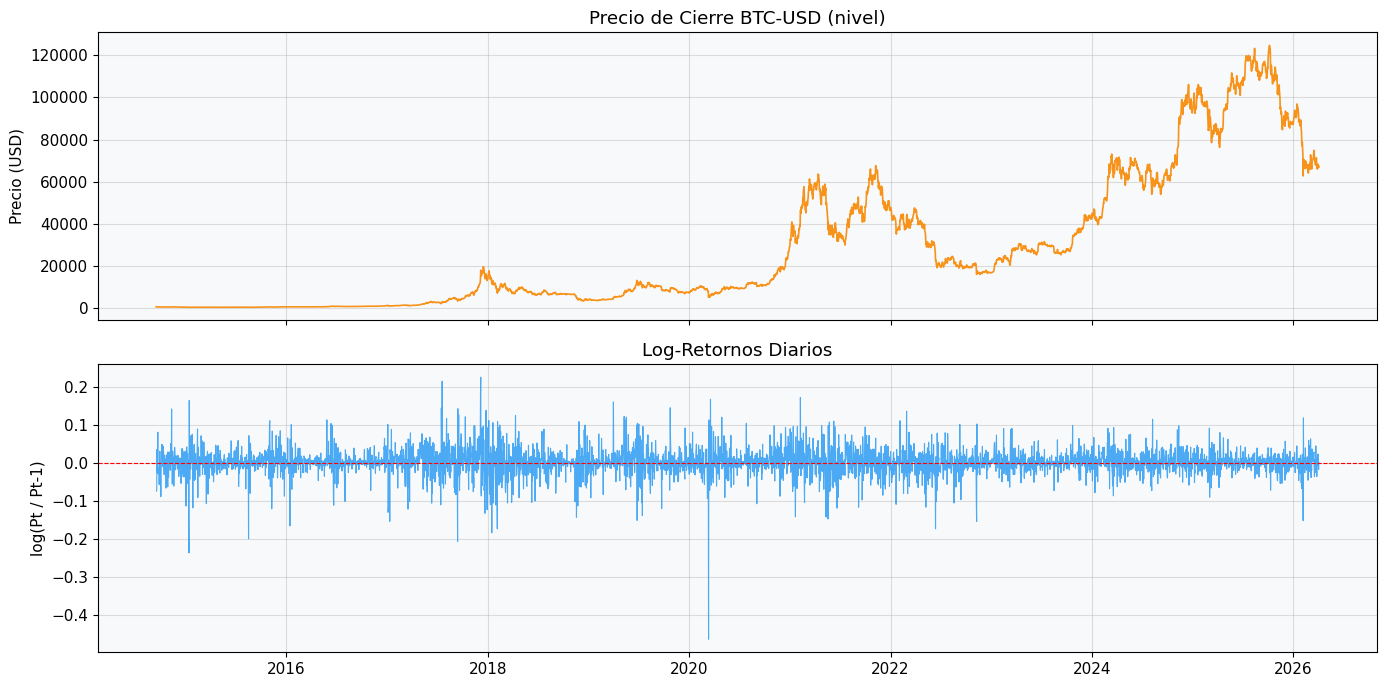

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(btc.index, btc.Price, color='#F7931A', lw=1.2)
axes[0].set_title('Precio de Cierre BTC-USD (nivel)')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(btc.index, btc.LogReturn, color='#2196F3', lw=0.8, alpha=0.8)
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('Log-Retornos Diarios')
axes[1].set_ylabel('log(Pt / Pt-1)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig1_serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()

:::{admonition} Conclusión — Capítulo 1
:class: tip

**Serie en nivel:** Tendencia estocástica pronunciada con múltiples ciclos de expansión y contracción. No estacionaria visualmente — se confirma formalmente en el Capítulo 2.

**Log-retornos:** Media aproximadamente cero pero con clusters de volatilidad marcados (COVID-19 en 2020, bull-run 2021, crash 2022). La curtosis elevada indica distribución leptocúrtica — colas más pesadas que la normal gaussiana.

**Implicación:** ARIMA modela la dinámica de la *media condicional*. La heterocedasticidad condicional observada requeriría un modelo GARCH complementario para capturar completamente la estructura de la serie.
:::